# 3b. LSTM Temporal Modeling on DCNN FC7 Features

Pipeline:
1. Load segment features (3x64x64) and labels.
2. Use trained DCNN to extract FC7 (4096-d) vectors per segment.
3. Build utterance-level segment sequences.
4. Train LSTM sequence classifier per split/fold.
5. Smooth segment predictions with sliding-window majority vote.
6. Evaluate with utterance-level metrics and Temporal IoU (t-IoU).

In [1]:
import os
import csv
from collections import defaultdict, Counter
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utility import EMOTION_ENG_MAP, EMOTION_CODE_MAP

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
CURR_DIR = os.getcwd()

# Update as needed
DATASET = "processed_emodb_comb_norm_loso"
SPLIT_MODE = "loso"  # "original" or "loso"

DATASET_PATH = os.path.join(CURR_DIR, DATASET)
MODEL_DIR = os.path.join(CURR_DIR, "models")
RESULTS_DIR = os.path.join(CURR_DIR, "results", DATASET)
os.makedirs(RESULTS_DIR, exist_ok=True)

RAW_TIMELINE_ROOT = os.path.abspath(os.path.join(CURR_DIR, "../emo_db_comb"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 7
HOP_MS = 0.010
WINDOW_MS = 0.025
SEG_FRAMES = 64
FRAME_SHIFT = 30
SEG_HOP_SEC = HOP_MS * FRAME_SHIFT
SEG_DUR_SEC = WINDOW_MS + (SEG_FRAMES - 1) * HOP_MS

SMOOTH_WINDOW = 5
TIOU_THRESHOLD = 0.50

if SPLIT_MODE == "loso":
    FOLD_NAMES = sorted([
        name for name in os.listdir(DATASET_PATH)
        if name.startswith("fold") and os.path.isdir(os.path.join(DATASET_PATH, name))
    ])
    if len(FOLD_NAMES) == 0:
        raise ValueError(f"No fold directories found under {DATASET_PATH}.")
else:
    FOLD_NAMES = []

print(f"DATASET_PATH: {DATASET_PATH}")
print(f"SPLIT_MODE: {SPLIT_MODE}")
if SPLIT_MODE == "loso":
    print(f"Folds: {FOLD_NAMES}")

DATASET_PATH: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/processed_emodb_comb_norm_loso
SPLIT_MODE: loso
Folds: ['fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9']


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((227, 227), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def build_fc7_extractor(model_path):
    model = models.alexnet()
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, NUM_CLASSES)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.classifier = nn.Sequential(*list(model.classifier.children())[:5])
    model.eval()
    return model.to(device)

def preprocess_segment_for_alexnet(seg):
    img = seg.copy()
    for c in range(3):
        mn, mx = img[c].min(), img[c].max()
        img[c] = (img[c] - mn) / (mx - mn) if mx > mn else 0.0
    img = img.transpose(1, 2, 0)
    return transform(img).float()

def extract_fc7_batch(segments, extractor, batch_size=64):
    tensors = torch.stack([preprocess_segment_for_alexnet(s) for s in segments], dim=0)
    outputs = []
    with torch.no_grad():
        for i in range(0, len(tensors), batch_size):
            b = tensors[i:i+batch_size].to(device=device, dtype=torch.float32)
            outputs.append(extractor(b).cpu())
    return torch.cat(outputs, dim=0).numpy()

In [5]:
def group_segments_by_utterance(X, y, utt_ids):
    grouped = defaultdict(lambda: {"segments": [], "labels": []})
    for seg, lbl, uid in zip(X, y, utt_ids):
        grouped[str(uid)]["segments"].append(seg)
        grouped[str(uid)]["labels"].append(int(lbl))
    return grouped

def build_sequences_from_split(dataset_dir, split_name, extractor):
    X = np.load(os.path.join(dataset_dir, f"X_{split_name}.npy"))
    y = np.load(os.path.join(dataset_dir, f"y_{split_name}.npy"))
    utt_ids = np.load(os.path.join(dataset_dir, f"utterance_ids_{split_name}.npy"))

    grouped = group_segments_by_utterance(X, y, utt_ids)
    seq_feats, seq_labels, seq_uids = [], [], []

    for uid, pack in grouped.items():
        seg_arr = np.array(pack["segments"])
        fc7 = extract_fc7_batch(seg_arr, extractor)
        seq_feats.append(torch.tensor(fc7, dtype=torch.float32))
        seq_labels.append(torch.tensor(pack["labels"], dtype=torch.long))
        seq_uids.append(uid)

    return seq_feats, seq_labels, seq_uids

class SequenceDataset(Dataset):
    def __init__(self, feats, labels, uids):
        self.feats = feats
        self.labels = labels
        self.uids = uids

    def __len__(self):
        return len(self.feats)

    def __getitem__(self, idx):
        return self.feats[idx], self.labels[idx], self.uids[idx]

def collate_sequences(batch):
    feats, labels, uids = zip(*batch)
    lengths = torch.tensor([len(x) for x in feats], dtype=torch.long)
    max_len = int(lengths.max().item())
    feat_dim = feats[0].shape[1]

    pad_feats = torch.zeros(len(batch), max_len, feat_dim, dtype=torch.float32)
    pad_labels = torch.full((len(batch), max_len), fill_value=-100, dtype=torch.long)

    for i, (f, l) in enumerate(zip(feats, labels)):
        T = len(f)
        pad_feats[i, :T] = f
        pad_labels[i, :T] = l

    return pad_feats, pad_labels, lengths, list(uids)

In [6]:
class LSTMTagger(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=1, num_classes=7, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.head(out)
        return logits

def smooth_labels(seq, window=5):
    if window <= 1 or len(seq) == 0:
        return list(seq)
    half = window // 2
    out = []
    for i in range(len(seq)):
        left = max(0, i - half)
        right = min(len(seq), i + half + 1)
        votes = Counter(seq[left:right])
        out.append(votes.most_common(1)[0][0])
    return out

def sequence_to_intervals(labels, seg_hop_sec=SEG_HOP_SEC, seg_dur_sec=SEG_DUR_SEC):
    if len(labels) == 0:
        return []
    intervals = []
    start_idx = 0
    curr = labels[0]
    for i in range(1, len(labels)):
        if labels[i] != curr:
            s = start_idx * seg_hop_sec
            e = (i - 1) * seg_hop_sec + seg_dur_sec
            intervals.append((s, e, curr))
            start_idx = i
            curr = labels[i]
    s = start_idx * seg_hop_sec
    e = (len(labels) - 1) * seg_hop_sec + seg_dur_sec
    intervals.append((s, e, curr))
    return intervals

def interval_iou(a_start, a_end, b_start, b_end):
    inter = max(0.0, min(a_end, b_end) - max(a_start, b_start))
    union = max(a_end, b_end) - min(a_start, b_start)
    return (inter / union) if union > 0 else 0.0

def dominant_label(intervals):
    if not intervals:
        return 0
    dur = defaultdict(float)
    for s, e, l in intervals:
        dur[int(l)] += max(0.0, e - s)
    return sorted(dur.items(), key=lambda x: (-x[1], x[0]))[0][0]

In [7]:
def load_timeline_lookup(root_dir):
    lookup = defaultdict(dict)
    if not os.path.isdir(root_dir):
        return lookup

    for name in sorted(os.listdir(root_dir)):
        if not name.startswith("speaker_"):
            continue
        spk = name.split("_")[-1]
        csv_path = os.path.join(root_dir, name, f"speaker_{spk}_timeline.csv")
        if not os.path.exists(csv_path):
            continue

        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                uid = row.get("generated_file", "").strip()
                code = row.get("emotion_code", "").strip()
                if uid == "" or code not in EMOTION_CODE_MAP:
                    continue
                s = float(row.get("start_sec", 0.0))
                e = float(row.get("end_sec", 0.0))
                lookup[spk].setdefault(uid, []).append((s, e, EMOTION_CODE_MAP[code]))

    for spk in lookup:
        for uid in lookup[spk]:
            lookup[spk][uid].sort(key=lambda x: x[0])
    return lookup

def compute_tiou(pred_intervals, gt_intervals, threshold=TIOU_THRESHOLD):
    if len(gt_intervals) == 0:
        return 0.0, 0.0

    best_ious = []
    for gs, ge, gl in gt_intervals:
        candidates = [
            interval_iou(gs, ge, ps, pe)
            for ps, pe, pl in pred_intervals
            if int(pl) == int(gl)
        ]
        best_ious.append(max(candidates) if candidates else 0.0)

    best_ious = np.array(best_ious)
    mean_tiou = float(best_ious.mean())
    success_rate = float((best_ious >= threshold).mean())
    return mean_tiou, success_rate

In [8]:
def train_lstm_one_run(train_loader, val_loader, max_epochs=20, lr=1e-3, hidden_dim=256):
    model = LSTMTagger(hidden_dim=hidden_dim, num_classes=NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    best_val = float('inf')
    best_state = None
    patience = 5
    bad = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for feats, labels, lengths, _ in train_loader:
            feats = feats.to(device)
            labels = labels.to(device)
            logits = model(feats)

            loss = criterion(logits.reshape(-1, NUM_CLASSES), labels.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for feats, labels, lengths, _ in val_loader:
                feats = feats.to(device)
                labels = labels.to(device)
                logits = model(feats)
                val_loss = criterion(logits.reshape(-1, NUM_CLASSES), labels.reshape(-1))
                val_losses.append(val_loss.item())

        tr = float(np.mean(train_losses)) if train_losses else 0.0
        va = float(np.mean(val_losses)) if val_losses else 0.0
        print(f"Epoch {epoch+1:02d} | train_loss={tr:.4f} | val_loss={va:.4f}")

        if va < best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def evaluate_lstm_sequences(model, loader, timeline_lookup):
    model.eval()
    utt_true_labels = []
    utt_pred_labels = []
    all_tiou = []
    all_success = []

    with torch.no_grad():
        for feats, labels, lengths, uids in loader:
            feats = feats.to(device)
            logits = model(feats).cpu().numpy()
            labels_np = labels.numpy()
            lengths_np = lengths.numpy()

            for b in range(len(uids)):
                T = int(lengths_np[b])
                uid = str(uids[b])

                pred_seq = np.argmax(logits[b, :T], axis=1).tolist()
                true_seq = labels_np[b, :T].tolist()

                pred_smoothed = smooth_labels(pred_seq, window=SMOOTH_WINDOW)
                pred_intervals = sequence_to_intervals(pred_smoothed)

                spk = uid[:2]
                gt_intervals = timeline_lookup.get(spk, {}).get(uid, None)
                if gt_intervals is None:
                    gt_intervals = sequence_to_intervals(true_seq)

                m_tiou, s_rate = compute_tiou(pred_intervals, gt_intervals, threshold=TIOU_THRESHOLD)
                all_tiou.append(m_tiou)
                all_success.append(s_rate)

                utt_true_labels.append(dominant_label(gt_intervals))
                utt_pred_labels.append(dominant_label(pred_intervals))

    return {
        "y_true_utt": np.array(utt_true_labels),
        "y_pred_utt": np.array(utt_pred_labels),
        "mean_tiou": float(np.mean(all_tiou)) if all_tiou else 0.0,
        "success_rate": float(np.mean(all_success)) if all_success else 0.0,
    }

In [9]:
timeline_lookup = load_timeline_lookup(RAW_TIMELINE_ROOT)

all_true = []
all_pred = []
fold_tious = []
fold_success = []

if SPLIT_MODE == "original":
    dcnn_path = os.path.join(MODEL_DIR, f"dcnn_{DATASET}.pth")
    if not os.path.exists(dcnn_path):
        raise FileNotFoundError(f"Missing DCNN checkpoint: {dcnn_path}")

    extractor = build_fc7_extractor(dcnn_path)
    tr_f, tr_l, tr_u = build_sequences_from_split(DATASET_PATH, "train", extractor)
    va_f, va_l, va_u = build_sequences_from_split(DATASET_PATH, "validation", extractor)
    te_f, te_l, te_u = build_sequences_from_split(DATASET_PATH, "test", extractor)

    train_loader = DataLoader(SequenceDataset(tr_f, tr_l, tr_u), batch_size=16, shuffle=True, collate_fn=collate_sequences)
    val_loader = DataLoader(SequenceDataset(va_f, va_l, va_u), batch_size=16, shuffle=False, collate_fn=collate_sequences)
    test_loader = DataLoader(SequenceDataset(te_f, te_l, te_u), batch_size=16, shuffle=False, collate_fn=collate_sequences)

    model = train_lstm_one_run(train_loader, val_loader)
    eval_out = evaluate_lstm_sequences(model, test_loader, timeline_lookup)

    all_true.extend(eval_out["y_true_utt"].tolist())
    all_pred.extend(eval_out["y_pred_utt"].tolist())
    fold_tious.append(eval_out["mean_tiou"])
    fold_success.append(eval_out["success_rate"])

else:
    for fold_name in FOLD_NAMES:
        print('=' * 80)
        print(f"Fold: {fold_name}")
        fold_path = os.path.join(DATASET_PATH, fold_name)
        dcnn_path = os.path.join(MODEL_DIR, f"dcnn_{DATASET}_{fold_name}.pth")
        if not os.path.exists(dcnn_path):
            raise FileNotFoundError(f"Missing DCNN checkpoint: {dcnn_path}")

        extractor = build_fc7_extractor(dcnn_path)
        tr_f, tr_l, tr_u = build_sequences_from_split(fold_path, "train", extractor)
        va_f, va_l, va_u = build_sequences_from_split(fold_path, "validation", extractor)
        te_f, te_l, te_u = build_sequences_from_split(fold_path, "test", extractor)

        train_loader = DataLoader(SequenceDataset(tr_f, tr_l, tr_u), batch_size=16, shuffle=True, collate_fn=collate_sequences)
        val_loader = DataLoader(SequenceDataset(va_f, va_l, va_u), batch_size=16, shuffle=False, collate_fn=collate_sequences)
        test_loader = DataLoader(SequenceDataset(te_f, te_l, te_u), batch_size=16, shuffle=False, collate_fn=collate_sequences)

        model = train_lstm_one_run(train_loader, val_loader)
        eval_out = evaluate_lstm_sequences(model, test_loader, timeline_lookup)

        fold_acc = accuracy_score(eval_out["y_true_utt"], eval_out["y_pred_utt"])
        print(f"Fold utterance-level accuracy: {fold_acc * 100:.2f}%")
        print(f"Fold mean t-IoU: {eval_out['mean_tiou']:.4f}")
        print(f"Fold t-IoU success@{TIOU_THRESHOLD:.2f}: {eval_out['success_rate'] * 100:.2f}%")

        all_true.extend(eval_out["y_true_utt"].tolist())
        all_pred.extend(eval_out["y_pred_utt"].tolist())
        fold_tious.append(eval_out["mean_tiou"])
        fold_success.append(eval_out["success_rate"])

y_true_final = np.array(all_true)
y_pred_final = np.array(all_pred)
final_acc = accuracy_score(y_true_final, y_pred_final)
final_report = classification_report(y_true_final, y_pred_final)
final_tiou = float(np.mean(fold_tious)) if fold_tious else 0.0
final_tiou_success = float(np.mean(fold_success)) if fold_success else 0.0

print('=' * 80)
print(f"Final utterance-level accuracy ({SPLIT_MODE}): {final_acc * 100:.2f}%")
print(f"Final mean t-IoU: {final_tiou:.4f}")
print(f"Final t-IoU success@{TIOU_THRESHOLD:.2f}: {final_tiou_success * 100:.2f}%")
print(final_report)

report_path = os.path.join(RESULTS_DIR, f"classification_report_lstm_{DATASET}.txt")
with open(report_path, "w") as f:
    f.write(f"Dataset: {DATASET}\n")
    f.write(f"Split mode: {SPLIT_MODE}\n")
    f.write(f"Utterance-level accuracy: {final_acc * 100:.2f}%\n")
    f.write(f"Mean t-IoU: {final_tiou:.4f}\n")
    f.write(f"t-IoU success@{TIOU_THRESHOLD:.2f}: {final_tiou_success * 100:.2f}%\n\n")
    f.write(final_report)
print(f"Saved LSTM report to: {report_path}")

Fold: fold1
Epoch 01 | train_loss=1.3189 | val_loss=1.2611
Epoch 02 | train_loss=0.9313 | val_loss=1.2297
Epoch 03 | train_loss=0.7951 | val_loss=1.2413
Epoch 04 | train_loss=0.7250 | val_loss=1.2171
Epoch 05 | train_loss=0.6850 | val_loss=1.2156
Epoch 06 | train_loss=0.6429 | val_loss=1.1967
Epoch 07 | train_loss=0.6367 | val_loss=1.1980
Epoch 08 | train_loss=0.6073 | val_loss=1.1939
Epoch 09 | train_loss=0.5941 | val_loss=1.1709
Epoch 10 | train_loss=0.5901 | val_loss=1.1549
Epoch 11 | train_loss=0.5832 | val_loss=1.1770
Epoch 12 | train_loss=0.5730 | val_loss=1.2846
Epoch 13 | train_loss=0.5640 | val_loss=1.1967
Epoch 14 | train_loss=0.5400 | val_loss=1.1960
Epoch 15 | train_loss=0.5244 | val_loss=1.1202
Epoch 16 | train_loss=0.5230 | val_loss=1.0443
Epoch 17 | train_loss=0.5178 | val_loss=1.0268
Epoch 18 | train_loss=0.5158 | val_loss=1.0374
Epoch 19 | train_loss=0.5132 | val_loss=1.2471
Epoch 20 | train_loss=0.5124 | val_loss=1.2029
Fold utterance-level accuracy: 61.22%
Fold mean 

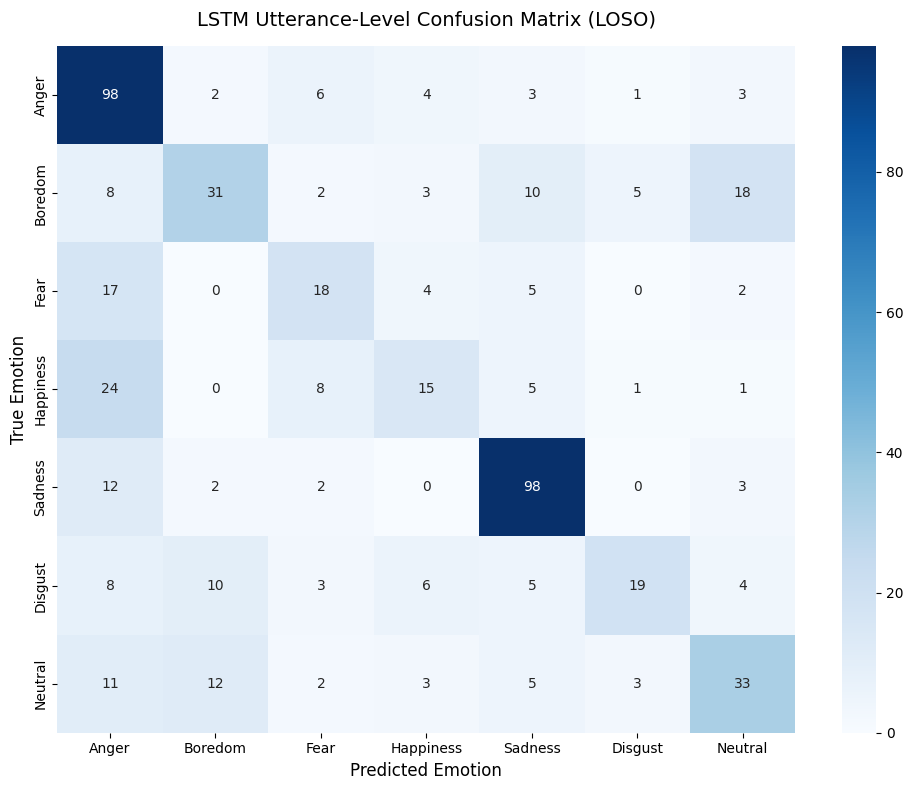

Saved LSTM confusion matrix to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso/confusion_lstm_processed_emodb_comb_norm_loso.png


In [10]:
EMOTION_NAMES = [EMOTION_ENG_MAP[i] for i in range(len(EMOTION_ENG_MAP))]
cm = confusion_matrix(y_true_final, y_pred_final, labels=np.arange(len(EMOTION_NAMES)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES)
plt.title(f'LSTM Utterance-Level Confusion Matrix ({SPLIT_MODE.upper()})', fontsize=14, pad=15)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, f"confusion_lstm_{DATASET}.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved LSTM confusion matrix to: {cm_path}")